In [1]:
import zipfile
from google.colab import files
import os

print("Please upload your zipped image dataset folder (e.g., 'images.zip').")

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a zip archive
  try:
    with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall(os.path.join(os.getcwd(), 'dataset')) # Extract to a 'dataset' folder
    print(f'Successfully extracted "{fn}" to the "dataset" folder.')
  except zipfile.BadZipFile:
    print(f'Error: "{fn}" is not a valid zip file. Please upload a zip archive.')
  except Exception as e:
    print(f'An unexpected error occurred: {e}')

# List the contents of the created 'dataset' folder to confirm
if os.path.exists('dataset'):
  print('\nContents of the \'dataset\' folder:')
  for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
      print(f'{subindent}{f}')
else:
  print('\nNo \'dataset\' folder was created.')

Please upload your zipped image dataset folder (e.g., 'images.zip').


Saving Flower_Dataset.zip to Flower_Dataset.zip
User uploaded file "Flower_Dataset.zip" with length 215160703 bytes
Successfully extracted "Flower_Dataset.zip" to the "dataset" folder.

Contents of the 'dataset' folder:
dataset/
    Flower_Dataset/
        train/
            tulip/
                8622237974_b362574785_n.jpg
                8523133474_d2c0845b54.jpg
                12025038686_7f10811d4b_n.jpg
                14067476586_36bcddf111.jpg
                14067761295_7cfe6a42e9.jpg
                13888320717_d2919a879b_m.jpg
                5810456385_b44358a0ae.jpg
                4520582070_d14a14f038.jpg
                4553203984_9cb9312240_n.jpg
                14266093711_66d18a1e44_n.jpg
                8712282563_3819afb7bc.jpg
                17198868382_697b23c715_n.jpg
                14068348874_7b36c99f6a.jpg
                12024561754_ce9667e4dc_n.jpg
                14087425312_2b5846b570_n.jpg
                6958243974_8851425ddb_n.jpg
                45

### 1. Check GPU Activity

Before building and training the model, we need to check if the GPU is available and active to ensure efficient training.

In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Specify GPU for TensorFlow
    tf.config.set_visible_devices(gpus[0], 'GPU')
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Handle GPU memory allocation errors during initialization
    print(e)
else:
  print("No GPU found. TensorFlow will use CPU.")

# Further check with a shell command (only works in environments with nvidia-smi)
try:
  !nvidia-smi
except Exception as e:
  print("Could not run nvidia-smi. Either no GPU is available or the command is not present.")

TensorFlow version: 2.20.0
1 Physical GPUs, 1 Logical GPUs
Sun May 24 04:40:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P0             27W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |             

### 2. Build and Train InceptionV3 Model

Next, we will build a model based on the pre-trained InceptionV3 architecture and train it on your image dataset.

In [9]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Base directory where the zip was extracted
base_data_path = 'dataset/Flower_Dataset'

# Define paths for training and testing data
train_data_path = os.path.join(base_data_path, 'train')
# The test_data_path is currently structured with images directly, not subfolders for classes.
# For now, we will use a validation_split from the training data.
# If you wish to use the 'test' folder for validation, please ensure it has class subdirectories.
# test_data_path = os.path.join(base_data_path, 'test')

# Input image size for InceptionV3
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

# Check the number of classes in the training dataset
# Expecting class subdirectories (e.g., 'tulip', 'rose') directly within train_data_path
class_names = sorted([name for name in os.listdir(train_data_path) if os.path.isdir(os.path.join(train_data_path, name))])
num_classes = len(class_names)

if num_classes == 0:
    raise ValueError(f"No class subdirectories found in '{train_data_path}'. Please ensure your data is organized as: {train_data_path}/class_1/images..., {train_data_path}/class_2/images...")

print(f"Found {num_classes} classes in the training directory: {class_names}")

# Prepare data using ImageDataGenerator
# Using validation_split on the training data for meaningful validation metrics
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Split 20% of training data for validation
)

train_generator = train_datagen.flow_from_directory(
    train_data_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training' # Specify training subset
)

validation_generator = train_datagen.flow_from_directory(
    train_data_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation' # Specify validation subset
)

# Load pre-trained InceptionV3 model on ImageNet
# `include_top=False` to exclude the final classification layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Freeze the layers of the base model so they are not re-trained
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers for your classification task
x = base_model.output
x = GlobalAveragePooling2D()(x)
# Additional Dense layers can be added here if needed
x = Dense(1024, activation='relu')(x)
# Use 'softmax' for multi-class classification
predictions = Dense(num_classes, activation='softmax')(x)

# Build the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display model structure
model.summary()

Found 5 classes in the training directory: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Found 2198 images belonging to 5 classes.
Found 548 images belonging to 5 classes.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_282 (Conv2D) │ (None, 149, 149,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_282[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_282      │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_283 (Conv2D) │ (None, 147, 147,  │      9,216 │ activation_282[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_283[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_283      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_284 (Conv2D) │ (None, 147, 147,  │     18,432 │ activation_283[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_284[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_284      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 73, 73,    │          0 │ activation_284[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_285 (Conv2D) │ (None, 73, 73,    │      5,120 │ max_pooling2d_12… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_285[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_285      │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_286 (Conv2D) │ (None, 71, 71,    │    138,240 │ activation_285[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_286[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_286      │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,906,085 (91.19 MB)

 Trainable params: 2,103,301 (8.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [10]:
EPOCHS = 25 # You can adjust the number of epochs

print(f"Starting model training for {EPOCHS} epochs...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

print("Training complete.")

Starting model training for 25 epochs...
Epoch 1/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.7329 - loss: 0.7400 - val_accuracy: 0.8175 - val_loss: 0.5067
Epoch 2/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 63s 899ms/step - accuracy: 0.8594 - loss: 0.4209 - val_accuracy: 0.8303 - val_loss: 0.4729
Epoch 3/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 62s 894ms/step - accuracy: 0.8717 - loss: 0.3596 - val_accuracy: 0.8084 - val_loss: 0.5210
Epoch 4/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 63s 914ms/step - accuracy: 0.8958 - loss: 0.3133 - val_accuracy: 0.8686 - val_loss: 0.3614
Epoch 5/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 62s 904ms/step - accuracy: 0.9076 - loss: 0.2766 - val_accuracy: 0.8449 - val_loss: 0.4161
Epoch 6/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 63s 919ms/step - accuracy: 0.9131 - loss: 0.2608 - val_accuracy: 0.8741 - val_loss: 0.3591
Epoch 7/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 62s 904ms/step - accuracy: 0.9149 - loss: 0.2500 - val_accuracy: 0.8777 - val_loss: 0.3402
Epoch 8/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 63s 916ms/step - acc

### 3. Summarize Training Results

After the model has been trained, we will review the performance metrics from the training process.

In [11]:
print("\n--- Final Training Results ---")

# Get final accuracy and loss from training history
final_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Training Loss: {final_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

print("\n--- Training History Summary ---")
# Print all keys in the history for user reference
for key, values in history.history.items():
    print(f"  {key}: [..., {values[-1]:.4f}]")


--- Final Training Results ---
Final Training Accuracy: 0.9759
Final Validation Accuracy: 0.8814
Final Training Loss: 0.0975
Final Validation Loss: 0.3848

--- Training History Summary ---
  accuracy: [..., 0.9759]
  loss: [..., 0.0975]
  val_accuracy: [..., 0.8814]
  val_loss: [..., 0.3848]


### 4. Display Training Plots

Loss and accuracy plots per epoch help us easily visualize the training process and evaluate model performance.

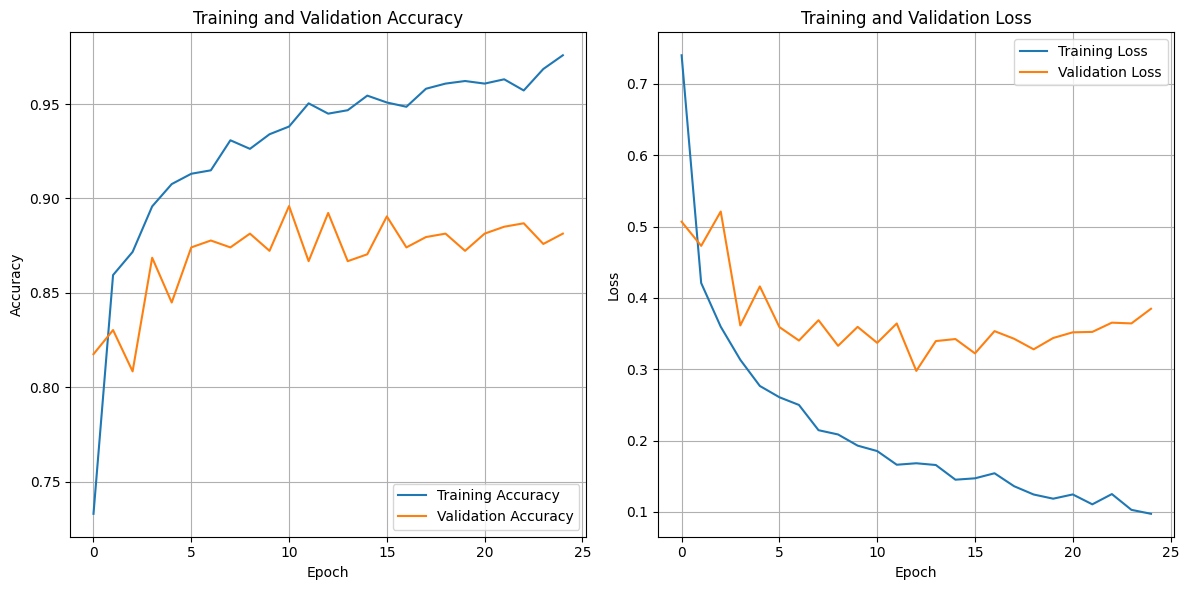

In [12]:
import matplotlib.pyplot as plt

# Get data from training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1) # 1 row, 2 columns, position 1
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2) # 1 row, 2 columns, position 2
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()